# Random Forest for Rainfall Classification

This notebook trains a **Random Forest** ensemble model using the **already preprocessed and encoded dataset**.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

candidate_paths = [
    Path("../data/processed/sri_lanka_weather_encoded.csv"),
    Path("../data/processed/sri_lanka_weather_processed.csv"),
    Path("data/processed/sri_lanka_weather_encoded.csv"),
    Path("data/processed/sri_lanka_weather_processed.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Processed dataset not found. Run 01_data_preprocessing.ipynb first.")

df = pd.read_csv(data_path)
print("Loaded file:", data_path)
print("Shape:", df.shape)
display(df.head())

possible_targets = ["rainfall_class_encoded", "rainfall_class"]
target_col = next((c for c in possible_targets if c in df.columns), None)
if target_col is None:
    raise ValueError("Target column not found. Expected 'rainfall_class_encoded' or 'rainfall_class'.")

if target_col == "rainfall_class":
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    df[target_col] = le.fit_transform(df[target_col])
    class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("Encoded rainfall_class automatically.")
    print("Class mapping:", class_mapping)

X = df.drop(columns=[target_col])
y = df[target_col]

# drop non-numeric columns if any remain
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print("Dropping non-numeric feature columns:", non_numeric)
    X = X.drop(columns=non_numeric)

print("Feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts().sort_index())

Loaded file: ..\data\processed\sri_lanka_weather_encoded.csv
Shape: (147480, 56)


,weathercode,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,shortwave_radiation_sum,precipitation_hours,windspeed_10m_max,windgusts_10m_max,et0_fao_evapotranspiration,elevation,year,month,day,day_of_week,quarter,is_weekend,day_length_hours,month_sin,month_cos,wind_dir_sin,wind_dir_cos,rainfall_class,rainfall_class_encoded,city_Athurugiriya,city_Badulla,city_Bentota,city_Colombo,city_Galle,city_Gampaha,city_Hambantota,city_Hatton,city_Jaffna,city_Kalmunai,city_Kalutara,city_Kandy,city_Kesbewa,city_Kolonnawa,city_Kurunegala,city_Mabole,city_Maharagama,city_Mannar,city_Matale,city_Matara,city_Moratuwa,city_Mount Lavinia,city_Negombo,city_Oruwala,city_Pothuhera,city_Puttalam,city_Ratnapura,city_Sri Jayewardenepura Kotte,city_Trincomalee,city_Weligama
0,2.0,30.0,22.7,26.1,34.4,25.2,29.2,20.92,0.0,11.7,27.4,4.58,16.0,2010.0,1.0,1.0,4.0,1.0,0.0,11.716667,0.5,0.866025,0.342020,0.939693,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,51.0,29.9,23.5,26.2,33.8,26.2,29.8,17.71,1.0,13.0,27.0,3.84,16.0,2010.0,1.0,2.0,5.0,1.0,1.0,11.733333,0.5,0.866025,0.406737,0.913545,Light Rain,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,51.0,29.5,23.2,26.0,34.3,26.3,29.9,17.76,3.0,12.3,27.4,3.65,16.0,2010.0,1.0,3.0,6.0,1.0,1.0,11.716667,0.5,0.866025,0.275637,0.961262,Light Rain,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,2.0,28.9,21.9,25.3,31.6,23.4,27.8,16.50,0.0,17.0,34.6,3.79,16.0,2010.0,1.0,4.0,0.0,1.0,0.0,11.733333,0.5,0.866025,-0.069756,0.997564,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,1.0,28.1,21.3,24.5,30.1,23.1,26.1,23.61,0.0,18.7,37.1,4.97,16.0,2010.0,1.0,5.0,1.0,1.0,0.0,11.733333,0.5,0.866025,-0.087156,0.996195,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


Dropping non-numeric feature columns: ['rainfall_class', 'city_Athurugiriya', 'city_Badulla', 'city_Bentota', 'city_Colombo', 'city_Galle', 'city_Gampaha', 'city_Hambantota', 'city_Hatton', 'city_Jaffna', 'city_Kalmunai', 'city_Kalutara', 'city_Kandy', 'city_Kesbewa', 'city_Kolonnawa', 'city_Kurunegala', 'city_Mabole', 'city_Maharagama', 'city_Mannar', 'city_Matale', 'city_Matara', 'city_Moratuwa', 'city_Mount Lavinia', 'city_Negombo', 'city_Oruwala', 'city_Pothuhera', 'city_Puttalam', 'city_Ratnapura', 'city_Sri Jayewardenepura Kotte', 'city_Trincomalee', 'city_Weligama']
Feature shape: (147480, 24)
Target distribution:
rainfall_class_encoded
0     9349
1    69341
2    42063
3    26727
Name: count, dtype: int64


## Train-test split and baseline model

In [2]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Train accuracy:", round(rf_model.score(X_train, y_train), 4))
print("Test accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Train accuracy: 0.9975
Test accuracy : 0.9699

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.91      1870
           1       0.98      0.98      0.98     13868
           2       0.94      0.96      0.95      8413
           3       1.00      1.00      1.00      5345

    accuracy                           0.97     29496
   macro avg       0.96      0.95      0.96     29496
weighted avg       0.97      0.97      0.97     29496



## Confusion matrix

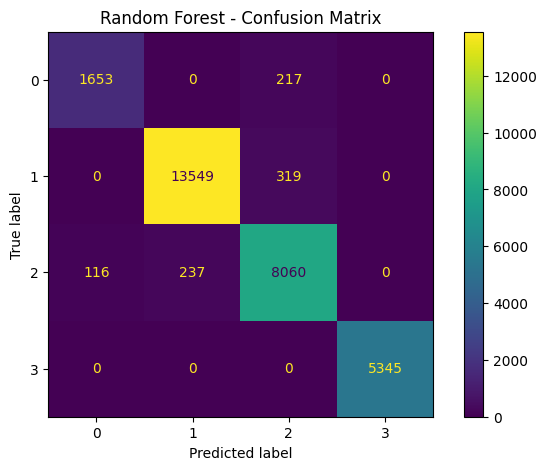

In [3]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

## Feature importance

,feature,importance
0,weathercode,0.318090
8,precipitation_hours,0.254353
11,et0_fao_evapotranspiration,0.080903
7,shortwave_radiation_sum,0.063992
3,temperature_2m_mean,0.027597
1,temperature_2m_max,0.022854
9,windspeed_10m_max,0.022461
10,windgusts_10m_max,0.020714
23,wind_dir_cos,0.018378
4,apparent_temperature_max,0.017577


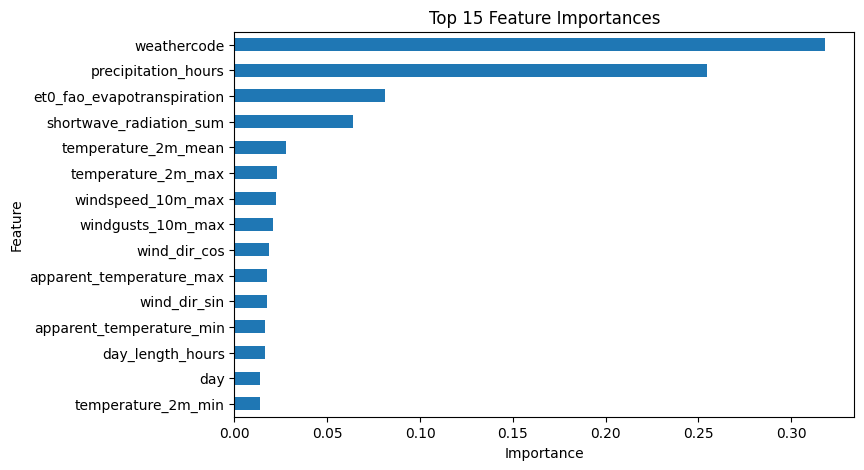

In [4]:
feature_importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": rf_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

display(feature_importance.head(15))

feature_importance.head(15).plot(
    kind="barh", x="feature", y="importance", legend=False
)
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Cross-validation

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)

print("Cross-validation scores:", np.round(cv_scores, 4))
print("Mean CV accuracy      :", round(cv_scores.mean(), 4))

Cross-validation scores: [0.9684 0.9696 0.9691 0.97   0.9714]
Mean CV accuracy      : 0.9697


## Hyperparameter tuning

In [6]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
best_pred = best_rf.predict(X_test)

print("Best parameters:", grid.best_params_)
print("Best CV score  :", round(grid.best_score_, 4))
print("Tuned test acc :", round(accuracy_score(y_test, best_pred), 4))
print("\nTuned Classification Report:")
print(classification_report(y_test, best_pred))

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score  : 0.9668
Tuned test acc : 0.9709

Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      1870
           1       0.98      0.98      0.98     13868
           2       0.94      0.96      0.95      8413
           3       1.00      1.00      1.00      5345

    accuracy                           0.97     29496
   macro avg       0.97      0.95      0.96     29496
weighted avg       0.97      0.97      0.97     29496



## Save best model

In [7]:
import joblib
Path("../models").mkdir(parents=True, exist_ok=True)
joblib.dump(best_rf, "../models/random_forest_model.pkl")
print("Saved: ../models/random_forest_model.pkl")

Saved: ../models/random_forest_model.pkl


## Predict on custom (unseen) input

In [ ]:
from pathlib import Path
import pandas as pd
import joblib

# Use the tuned model if available; otherwise load the saved model
if "best_rf" in globals():
    model = best_rf
else:
    model_path = Path("../models/random_forest_model.pkl")
    if not model_path.exists():
        raise FileNotFoundError("Model not found at ../models/random_forest_model.pkl. Run the training/tuning cells first.")
    model = joblib.load(model_path)

# Get expected feature columns
if "X" in globals():
    feature_cols = list(X.columns)
elif hasattr(model, "feature_names_in_"):
    feature_cols = list(model.feature_names_in_)
else:
    raise ValueError("Can't infer feature columns. Run the data loading cell first so X is available.")

# Enter your custom values here (edit as needed)
custom_values = {
    'weathercode': 2.0,
    'temperature_2m_max': 28.0,
    'temperature_2m_min': 20.0,
    'temperature_2m_mean': 24.0,
    'apparent_temperature_max': 30.0,
    'apparent_temperature_min': 22.0,
    'apparent_temperature_mean': 26.0,
    'shortwave_radiation_sum': 20.0,
    'precipitation_hours': 0.0,
    'windspeed_10m_max': 10.0,
    'windgusts_10m_max': 25.0,
    'et0_fao_evapotranspiration': 4.0,
    'elevation': 100.0,
    'year': 2023.0,
    'month': 7.0,
    'day': 15.0,
    'day_of_week': 5.0,
    'quarter': 3.0,
    'is_weekend': 1.0,
    'day_length_hours': 12.5,
    'month_sin': 0.866,
    'month_cos': -0.5,
    'wind_dir_sin': 0.707,
    'wind_dir_cos': 0.707,
    'city_Colombo': 1.0,
}

# Build a single-row input with all expected features
input_df = pd.DataFrame(0.0, index=[0], columns=feature_cols)

unknown = []
for key, value in custom_values.items():
    if key in input_df.columns:
        input_df.at[0, key] = float(value)
    else:
        unknown.append(key)

if unknown:
    print("Warning: these custom_values keys are not in the model features and were ignored:")
    print(unknown)

pred = model.predict(input_df)[0]

# If a LabelEncoder exists (only when target was 'rainfall_class'), decode back to class name
if "le" in globals():
    pred_label = le.inverse_transform([int(pred)])[0]
else:
    pred_label = pred

print("Predicted Rainfall Class:", pred_label)

['city_Colombo']
Predicted Rainfall Class: 3
